# Spectra & summary statistics
Beyond scalar moments, the {class}`~phasegen.distributions.Coalescent` provides full *spectra* — the joint (multi-population) and two-locus site-frequency spectra — as well as a set of standard scalar summary statistics. All of these are exact and respect the full demography and coalescent model. See {doc}`coalescent` for how to configure the underlying model.

In [1]:
import phasegen as pg
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = (5, 4)

## Joint site-frequency spectrum
For multiple populations, {meth}`~phasegen.distributions.Coalescent.jsfs` gives the *joint* (multi-population) SFS: the expected branch length subtending each configuration of derived-allele counts *per population* (the deme of origin). For ``P`` populations it is a ``P``-dimensional {class}`~phasegen.spectrum.JointSFS` of shape ``(n_0 + 1, ..., n_{P-1} + 1)``, with higher moments available via ``moment(k)``, ``var`` and ``cov``. It is restricted to a single locus, and the state space grows quickly with the per-population sample sizes, so keep these small.

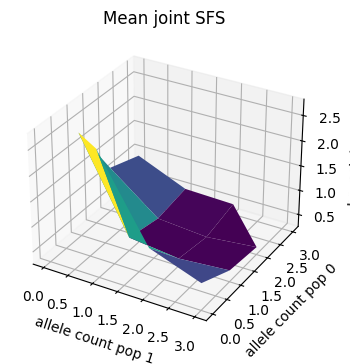

In [2]:
# a two-population demography with a population-size change and asymmetric migration
coal = pg.Coalescent(
    n={'pop_0': 3, 'pop_1': 3},
    demography=pg.Demography(
        pop_sizes={'pop_0': {0: 1, 1: 0.3}, 'pop_1': {0: 1.5}},
        migration_rates={('pop_0', 'pop_1'): 0.5, ('pop_1', 'pop_0'): 0.2},
    ),
)

# mean joint SFS: expected branch length subtending each (pop_0, pop_1) allele-frequency configuration
coal.jsfs.mean.plot_surface(title='Mean joint SFS');

## Two-locus SFS under recombination
For two loci separated by recombination rate ``r``, {meth}`~phasegen.distributions.Coalescent.sfs2` gives the *two-locus* SFS: entry ``(i, j)`` is the expected product of the branch length subtending ``i`` samples at locus 0 and ``j`` samples at locus 1. It is a {class}`~phasegen.spectrum.TwoLocusSFS` and interpolates between the within-tree SFS covariance at ``r = 0`` (fully linked) and independent loci as ``r → ∞`` (for the standard coalescent). The starting linkage is set via the {class}`~phasegen.locus.LocusConfig` ``n_unlinked``. A single population is supported, and the state space grows quickly with the sample size.

The single- and two-locus spectra guard each other: {meth}`~phasegen.distributions.Coalescent.sfs2` requires exactly two loci, while the single-locus {meth}`~phasegen.distributions.Coalescent.sfs` requires one (its marginal mean is recombination-invariant, so to obtain it for one locus simply drop the other).

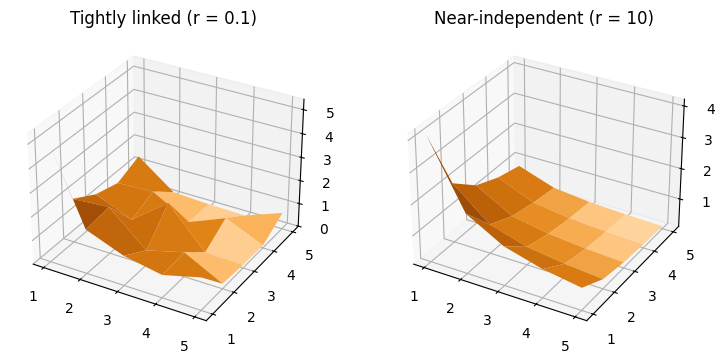

In [3]:
# the two-locus SFS interpolates between tightly linked and independent loci as r grows
_, axs = plt.subplots(ncols=2, figsize=(9, 4), subplot_kw={"projection": "3d"})

# r = 0.1: tightly linked -> strong cross-locus structure (close to the within-tree SFS covariance)
pg.Coalescent(n=6, loci=2, recombination_rate=0.1).sfs2.mean.plot_surface(
    ax=axs[0], show=False, title='Tightly linked (r = 0.1)')

# r = 10: nearly independent -> approaches the outer product of the marginal SFS
pg.Coalescent(n=6, loci=2, recombination_rate=10.0).sfs2.mean.plot_surface(
    ax=axs[1], title='Near-independent (r = 10)');

## Summary statistics
Beyond full spectra, several standard scalar summaries are available directly from the {class}`~phasegen.distributions.Coalescent`, each respecting the full demography and coalescent model:

- **Population structure** — Hudson's {meth}`~phasegen.distributions.Coalescent.fst` and Patterson's f-statistics ({meth}`~phasegen.distributions.Coalescent.f2`, {meth}`~phasegen.distributions.Coalescent.f3`, {meth}`~phasegen.distributions.Coalescent.f4`), all derived from inter-population pairwise coalescence times.
- **Linkage** — the correlation of coalescence times between two loci (``tree_height.loci.get_corr``), which decays towards zero as the recombination rate grows.
- **SFS skew** — Tajima's {meth}`~phasegen.distributions.UnfoldedSFSDistribution.tajimas_d`, together with the underlying ``theta_pi`` and ``theta_w`` estimators.

We illustrate them on a relatively complex scenario: a structured three-population demography with asymmetric population sizes and migration.

In [4]:
# a structured three-population demography with migration
struct = pg.Coalescent(
    n={'pop_0': 2, 'pop_1': 2, 'pop_2': 2},
    demography=pg.Demography(
        pop_sizes={'pop_0': 1.0, 'pop_1': 1.0, 'pop_2': 1.5},
        migration_rates={
            ('pop_0', 'pop_1'): 0.5, ('pop_1', 'pop_0'): 0.5,
            ('pop_1', 'pop_2'): 0.2, ('pop_2', 'pop_1'): 0.2,
            ('pop_0', 'pop_2'): 0.2, ('pop_2', 'pop_0'): 0.2,
        },
    ),
)

# population structure: Hudson's F_ST and Patterson's f-statistics
print(f"F_ST                    = {struct.fst:.3f}")
print(f"f2(pop_0, pop_2)        = {struct.f2('pop_0', 'pop_2'):.3f}")
print(f"f3(pop_1; pop_0, pop_2) = {struct.f3('pop_1', 'pop_0', 'pop_2'):.3f}")

# linkage: correlation of coalescence times between two loci, decaying with recombination
for r in [0.1, 1.0, 10.0]:
    corr = pg.Coalescent(n=2, loci=2, recombination_rate=r).tree_height.loci.get_corr(0, 1)
    print(f"corr(T_A, T_B) at r={r:<4} = {corr:.3f}")

# SFS skew: Tajima's D under recent population growth (excess of low-frequency variants -> D < 0)
growth = pg.Coalescent(n=10, demography=pg.Demography(pop_sizes={'pop_0': {0: 1.0, 0.5: 0.1}}))
print(f"Tajima's D (growth)     = {growth.sfs.tajimas_d:.3f}")

F_ST                    = 0.348
f2(pop_0, pop_2)        = 4.097
f3(pop_1; pop_0, pop_2) = 1.361
corr(T_A, T_B) at r=0.1  = 0.882
corr(T_A, T_B) at r=1.0  = 0.417
corr(T_A, T_B) at r=10.0 = 0.056
Tajima's D (growth)     = -1.263
